In [76]:
import pandas as pd
import matplotlib.pyplot as plt

In [77]:
btc = pd.read_parquet('/Crypto_QTS_Data_Processed/btc_price_processed.parquet')

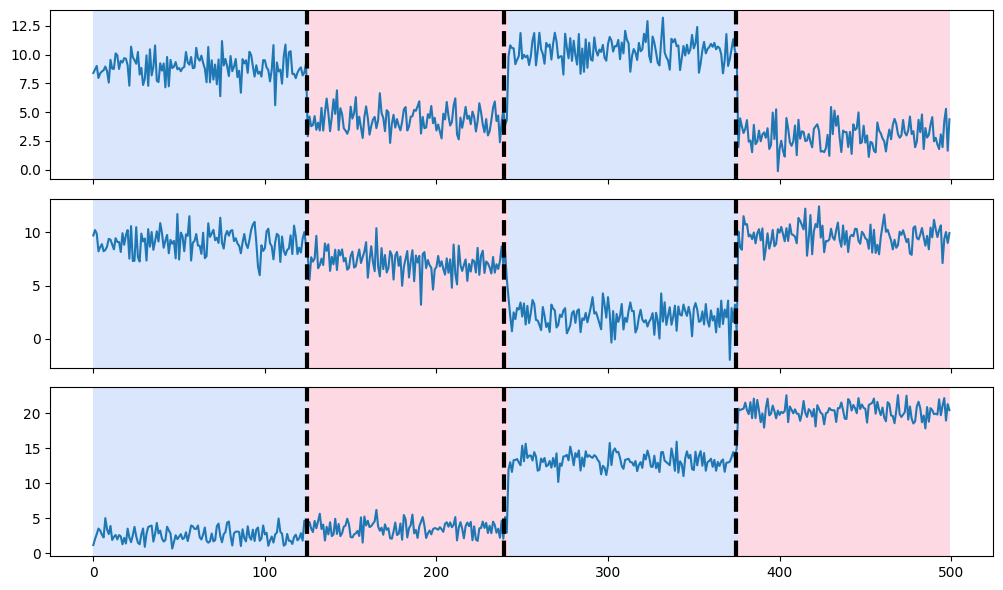

In [78]:
import numpy as np
import matplotlib.pylab as plt
import ruptures as rpt

# creation of data
n, dim = 500, 3
n_bkps, sigma = 3, 1
signal, bkps = rpt.pw_constant(n, dim, n_bkps, noise_std=sigma)

# change point detection
model = "rbf"  # "l2", "rbf"
algo = rpt.Pelt(model=model, min_size=3, jump=5).fit(signal)
my_bkps = algo.predict(pen=3)

# show results
fig, ax_arr = rpt.display(signal, bkps, my_bkps, figsize=(10, 6))
plt.show()

In [79]:
btc = btc[['price_close']]


In [80]:
numpy_btc = btc.to_numpy()

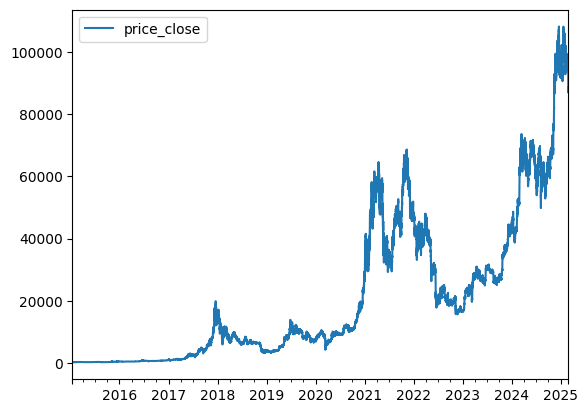

In [81]:
btc.plot()
plt.show()

In [82]:
# c = rpt.KernelCPD(kernel = "rbf", min_size=3).fit(num)
# result = c.predict(pen = 7)
# print(result)

In [83]:
# c = rpt.BottomUp(model="rbf", min_size=3, jump=5).fit(numpy_btc)
# result = c.predict(pen=7)

In [84]:
# c = rpt.Pelt(model = 'rbf', min_size=3, jump=24).fit(numpy_btc)
# result = c.predict(pen=3)

In [85]:
# fig, ax_arr = rpt.display(signal, bkps, my_bkps, figsize=(10, 6))
# plt.show()

In [86]:
btc

,price_close
2015-01-14 17:00:00+00:00,185.91
2015-01-14 18:00:00+00:00,185.91
2015-01-14 19:00:00+00:00,186.00
2015-01-14 20:00:00+00:00,120.00
2015-01-14 21:00:00+00:00,120.00
...,...
2025-02-25 20:00:00+00:00,87825.05
2025-02-25 21:00:00+00:00,88044.47
2025-02-25 22:00:00+00:00,88706.81
2025-02-25 23:00:00+00:00,88740.03


In [87]:
daily = btc.loc[::24]
daily_numpy = daily.to_numpy()

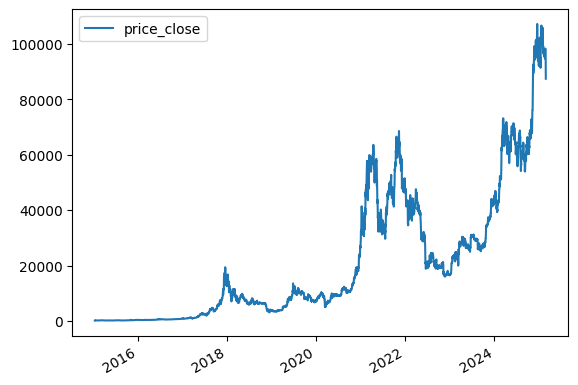

In [88]:
daily.plot()
plt.show()

In [89]:
c = rpt.Pelt(model = "rbf", min_size=3, jump=5).fit(daily.values)
model = c.predict(pen=30)


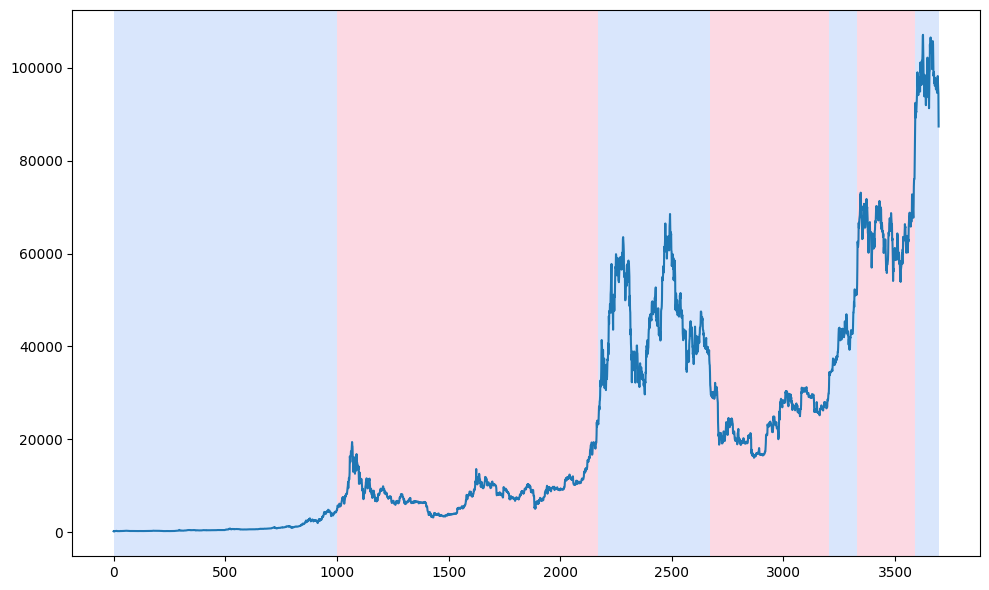

In [90]:
fig, ax_arr = rpt.display(daily.values, model, figsize=(10, 6))
plt.show()

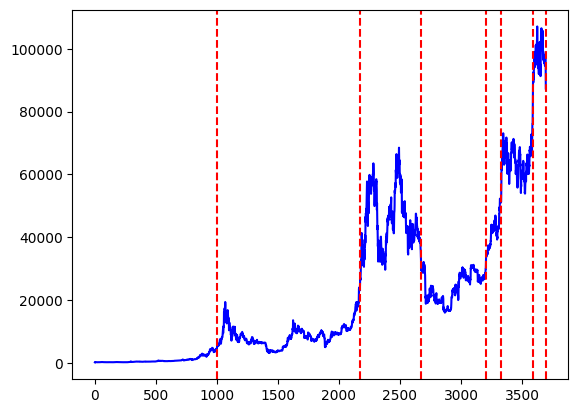

In [91]:
fig, ax = plt.subplots()
ax.plot(daily.values, color = 'b')
for r in model:
    ax.axvline(x = r, color = 'r', linestyle = '--')

In [92]:
model

[1000, 2170, 2670, 3205, 3330, 3590, 3696]

In [170]:
y = daily.reset_index()
dates = []
for m in model:
    m = m-1
    dates.append(y.loc[m, 'index'])


In [171]:
dates

[Timestamp('2017-10-09 17:00:00+0000', tz='UTC'),
 Timestamp('2020-12-22 17:00:00+0000', tz='UTC'),
 Timestamp('2022-05-06 17:00:00+0000', tz='UTC'),
 Timestamp('2023-10-23 17:00:00+0000', tz='UTC'),
 Timestamp('2024-02-25 17:00:00+0000', tz='UTC'),
 Timestamp('2024-11-11 17:00:00+0000', tz='UTC'),
 Timestamp('2025-02-25 17:00:00+0000', tz='UTC')]

In [48]:
btc.reset_index()

,index,price_close
0,2015-01-14 17:00:00+00:00,185.91
1,2015-01-14 18:00:00+00:00,185.91
2,2015-01-14 19:00:00+00:00,186.00
3,2015-01-14 20:00:00+00:00,120.00
4,2015-01-14 21:00:00+00:00,120.00
...,...,...
88683,2025-02-25 20:00:00+00:00,87825.05
88684,2025-02-25 21:00:00+00:00,88044.47
88685,2025-02-25 22:00:00+00:00,88706.81
88686,2025-02-25 23:00:00+00:00,88740.03


In [75]:
btc

,level_0,index,price_close
0,0,2015-01-14 17:00:00+00:00,185.91
1,1,2015-01-14 18:00:00+00:00,185.91
2,2,2015-01-14 19:00:00+00:00,186.00
3,3,2015-01-14 20:00:00+00:00,120.00
4,4,2015-01-14 21:00:00+00:00,120.00
...,...,...,...
88683,88683,2025-02-25 20:00:00+00:00,87825.05
88684,88684,2025-02-25 21:00:00+00:00,88044.47
88685,88685,2025-02-25 22:00:00+00:00,88706.81
88686,88686,2025-02-25 23:00:00+00:00,88740.03


In [147]:
dfs = {}
dfs_summary = {}
for j in range(len(dates) - 1):  # Prevent IndexError
    start_date = dates[j]
    end_date = dates[j+1]
    df = btc.copy()
    df.reset_index(inplace = True)
    df_filtered = df[(df["index"] >= start_date) & (df["index"] < end_date)]
    df_filtered['start_date'] = start_date
    df_filtered['end_date'] = end_date

    dfs[f"df_{j}"] = df_filtered



/var/folders/hq/47ww7tn11ss9dm7r1n54_hlr0000gn/T/ipykernel_19216/440593347.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['start_date'] = start_date
/var/folders/hq/47ww7tn11ss9dm7r1n54_hlr0000gn/T/ipykernel_19216/440593347.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['end_date'] = end_date# Filter
/var/folders/hq/47ww7tn11ss9dm7r1n54_hlr0000gn/T/ipykernel_19216/440593347.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

In [168]:
dfs.get('df_0')

,index,price_close,start_date,end_date
23976,2017-10-09 17:00:00+00:00,4644.24,2017-10-09 17:00:00+00:00,2020-12-22 17:00:00+00:00
23977,2017-10-09 18:00:00+00:00,4700.31,2017-10-09 17:00:00+00:00,2020-12-22 17:00:00+00:00
23978,2017-10-09 19:00:00+00:00,4750.00,2017-10-09 17:00:00+00:00,2020-12-22 17:00:00+00:00
23979,2017-10-09 20:00:00+00:00,4801.36,2017-10-09 17:00:00+00:00,2020-12-22 17:00:00+00:00
23980,2017-10-09 21:00:00+00:00,4842.18,2017-10-09 17:00:00+00:00,2020-12-22 17:00:00+00:00
...,...,...,...,...
52051,2020-12-22 12:00:00+00:00,23119.10,2017-10-09 17:00:00+00:00,2020-12-22 17:00:00+00:00
52052,2020-12-22 13:00:00+00:00,23182.44,2017-10-09 17:00:00+00:00,2020-12-22 17:00:00+00:00
52053,2020-12-22 14:00:00+00:00,23487.05,2017-10-09 17:00:00+00:00,2020-12-22 17:00:00+00:00
52054,2020-12-22 15:00:00+00:00,23439.56,2017-10-09 17:00:00+00:00,2020-12-22 17:00:00+00:00


In [166]:
dfs_summary = {}

for k, v in dfs.items():
    mean = v['price_close'].mean()
    std = v['price_close'].std()
    start_date = (v['start_date'].values[1])
    end_date = (v['end_date'].values[1])

    dfs_summary[k] = {'mean': mean, 'std': std, 'start_date': start_date, 'end_date': end_date}

dfs_summary_df = pd.DataFrame.from_dict(dfs_summary, orient='index')

In [167]:
dfs_summary_df

,mean,std,start_date,end_date
df_0,8606.897153,3389.097937,2017-10-09 17:00:00,2020-12-22 17:00:00
df_1,45439.144218,9335.616547,2020-12-22 17:00:00,2022-05-06 17:00:00
df_2,24197.495011,4546.286601,2022-05-06 17:00:00,2023-10-23 17:00:00
df_3,41710.701133,4856.425256,2023-10-23 17:00:00,2024-02-25 17:00:00
df_4,64413.884960,4716.358386,2024-02-25 17:00:00,2024-11-11 17:00:00
df_5,97602.851482,4157.387892,2024-11-11 17:00:00,2025-02-25 17:00:00


In [138]:
dfs.keys()

dict_keys(['df_0', 'df_1', 'df_2', 'df_3', 'df_4', 'df_5'])

In [121]:
dfs.get('df_0')['mean'] = dfs.get('df_0')['price_close'].mean()
print(dfs.get('df_0'))

                          index  price_close         mean
23976 2017-10-09 17:00:00+00:00      4644.24  8606.897153
23977 2017-10-09 18:00:00+00:00      4700.31  8606.897153
23978 2017-10-09 19:00:00+00:00      4750.00  8606.897153
23979 2017-10-09 20:00:00+00:00      4801.36  8606.897153
23980 2017-10-09 21:00:00+00:00      4842.18  8606.897153
...                         ...          ...          ...
52051 2020-12-22 12:00:00+00:00     23119.10  8606.897153
52052 2020-12-22 13:00:00+00:00     23182.44  8606.897153
52053 2020-12-22 14:00:00+00:00     23487.05  8606.897153
52054 2020-12-22 15:00:00+00:00     23439.56  8606.897153
52055 2020-12-22 16:00:00+00:00     23345.43  8606.897153

[28080 rows x 3 columns]


/var/folders/hq/47ww7tn11ss9dm7r1n54_hlr0000gn/T/ipykernel_19216/843034218.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs.get('df_0')['mean'] = dfs.get('df_0')['price_close'].mean()


In [102]:
dfs.get('df_1')


,index,price_close
52056,2020-12-22 17:00:00+00:00,23348.71
52057,2020-12-22 18:00:00+00:00,23341.58
52058,2020-12-22 19:00:00+00:00,23434.72
52059,2020-12-22 20:00:00+00:00,23409.97
52060,2020-12-22 21:00:00+00:00,23436.66
...,...,...
64052,2022-05-06 13:00:00+00:00,35818.72
64053,2022-05-06 14:00:00+00:00,35733.43
64054,2022-05-06 15:00:00+00:00,36132.79
64055,2022-05-06 16:00:00+00:00,35981.57


In [110]:
for key,value in dfs:


SyntaxError: 'return' outside function (613464093.py, line 2)

In [112]:
dfs.values()

dict_values([                          index  price_close
23976 2017-10-09 17:00:00+00:00      4644.24
23977 2017-10-09 18:00:00+00:00      4700.31
23978 2017-10-09 19:00:00+00:00      4750.00
23979 2017-10-09 20:00:00+00:00      4801.36
23980 2017-10-09 21:00:00+00:00      4842.18
...                         ...          ...
52051 2020-12-22 12:00:00+00:00     23119.10
52052 2020-12-22 13:00:00+00:00     23182.44
52053 2020-12-22 14:00:00+00:00     23487.05
52054 2020-12-22 15:00:00+00:00     23439.56
52055 2020-12-22 16:00:00+00:00     23345.43

[28080 rows x 2 columns],                           index  price_close
52056 2020-12-22 17:00:00+00:00     23348.71
52057 2020-12-22 18:00:00+00:00     23341.58
52058 2020-12-22 19:00:00+00:00     23434.72
52059 2020-12-22 20:00:00+00:00     23409.97
52060 2020-12-22 21:00:00+00:00     23436.66
...                         ...          ...
64051 2022-05-06 12:00:00+00:00     35775.51
64052 2022-05-06 13:00:00+00:00     35818.72
64053 2022-05-0